# `log_20260330_161922.csv` Review

This notebook reviews the first HFE fill / empty / slow-recirculation log.

The main goal is to avoid treating the entire file as one clean steady-state run:

- the pump is repeatedly turned on and off,
- the early windows include obvious priming / draining behaviour, and
- only a subset of the file looks suitable for quantitative recirculation plots.

The notebook therefore:

1. loads the raw log,
2. converts the legacy flow-meter columns into canonical SI units when needed,
3. identifies pump-active segments,
4. classifies each segment qualitatively, and
5. focuses the detailed plots on the short windows that actually look usable.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import orca
from matplotlib.ticker import LinearLocator
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

LOG_PATH = REPO_ROOT / 'data' / 'raw' / 'log_20260330_161922.csv'
print(f'Repo root: {REPO_ROOT}')
print(f'Log path: {LOG_PATH}')


Repo root: /home/aamy/Documents/hfe-system
Log path: /home/aamy/Documents/hfe-system/data/raw/log_20260330_161922.csv


In [2]:
LB_TO_KG = 0.45359237
US_GAL_TO_M3 = 0.003785411784
FT_TO_M = 0.3048
LB_PER_GAL_TO_KG_PER_M3 = LB_TO_KG / US_GAL_TO_M3
HFE_LIQUID_DENSITY_BOUNDS = (1200.0, 1600.0)


def detect_legacy_flow_export(frame: pd.DataFrame) -> bool:
    """Heuristic for the older CSV schema used in this log."""

    required = {'fluid_temperature_raw', 'fluid_density_kg_m3'}
    if not required.issubset(frame.columns):
        return False

    temp_raw = frame['fluid_temperature_raw'].dropna()
    density_raw = frame['fluid_density_kg_m3'].dropna()
    if temp_raw.empty or density_raw.empty:
        return False

    return temp_raw.median() > 40.0 and density_raw.quantile(0.95) < 20.0


def add_canonical_flow_columns(frame: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    data = frame.copy()
    legacy = detect_legacy_flow_export(data)

    if legacy:
        note = (
            'This CSV looks like a legacy export: the flow-meter columns behave like '
            'ft/s, US gal/min, lb/min, degF and lb/gal even though the headers look SI. '
            'The notebook converts them to canonical SI before plotting.'
        )
        data['flow_velocity_mps_si'] = data['fluid_flow_velocity_mps'] * FT_TO_M
        data['volume_flow_m3s_si'] = data['fluid_volume_flow_m3s'] * US_GAL_TO_M3 / 60.0
        data['volume_flow_lmin_si'] = data['fluid_volume_flow_m3s'] * US_GAL_TO_M3 * 1000.0
        data['mass_flow_kgs_si'] = data['fluid_mass_flow_kgs'] * LB_TO_KG / 60.0
        data['mass_flow_kgmin_si'] = data['fluid_mass_flow_kgs'] * LB_TO_KG
        data['temperature_c_si'] = (data['fluid_temperature_raw'] - 32.0) * 5.0 / 9.0
        data['density_kg_m3_si'] = data['fluid_density_kg_m3'] * LB_PER_GAL_TO_KG_PER_M3
    else:
        note = 'This CSV already looks SI-like, so the notebook uses the logged flow-meter columns directly.'
        data['flow_velocity_mps_si'] = data.get('fluid_flow_velocity_mps', np.nan)
        data['volume_flow_m3s_si'] = data.get('fluid_volume_flow_m3s', np.nan)
        data['volume_flow_lmin_si'] = data['volume_flow_m3s_si'] * 60.0 * 1000.0
        data['mass_flow_kgs_si'] = data.get('fluid_mass_flow_kgs', np.nan)
        data['mass_flow_kgmin_si'] = data['mass_flow_kgs_si'] * 60.0
        if 'fluid_temperature_c' in data.columns:
            data['temperature_c_si'] = data['fluid_temperature_c']
        elif 'fluid_temperature_raw' in data.columns:
            data['temperature_c_si'] = data['fluid_temperature_raw'] - 273.15
        else:
            data['temperature_c_si'] = np.nan
        data['density_kg_m3_si'] = data.get('fluid_density_kg_m3', np.nan)

    data['pump_running'] = data['pump_freq_hz'].fillna(0.0) > 0.5
    lo, hi = HFE_LIQUID_DENSITY_BOUNDS
    data['liquid_like_density'] = data['density_kg_m3_si'].between(lo, hi)
    data['positive_mass_flow'] = data['mass_flow_kgmin_si'] > 0.0
    data['usable_sample'] = data['pump_running'] & data['liquid_like_density']
    data['delta_p_bar_recomputed'] = data['pump_pressure_after_bar_abs'] - data['pump_pressure_before_bar_abs']
    data['t_min'] = data['time_s'] / 60.0
    return data, note


def contiguous_true_segments(mask: pd.Series) -> list[tuple[int, int]]:
    values = mask.fillna(False).to_numpy()
    segments: list[tuple[int, int]] = []
    start = None
    for idx, flag in enumerate(values):
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            segments.append((start, idx - 1))
            start = None
    if start is not None:
        segments.append((start, len(values) - 1))
    return segments


def classify_segment(row: pd.Series) -> str:
    if row['liquid_fraction'] < 0.50:
        return 'gas-rich / empty'
    if row['positive_mass_flow_fraction'] < 0.75:
        return 'priming / flow-direction flips'
    if row['liquid_fraction'] < 0.90:
        return 'draining tail / mixed phase'
    if row['duration_s'] < 20.0:
        return 'short usable window'
    return 'usable liquid circulation'


def build_segment_summary(data: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    for segment_id, (start, end) in enumerate(contiguous_true_segments(data['pump_running']), start=1):
        seg = data.iloc[start:end + 1]
        cmd_levels = sorted({v for v in seg['pump_cmd_pct'].dropna().round(1) if abs(v) > 1e-9})
        row = {
            'segment_id': segment_id,
            'start_s': seg['time_s'].iloc[0],
            'end_s': seg['time_s'].iloc[-1],
            'duration_s': seg['time_s'].iloc[-1] - seg['time_s'].iloc[0],
            'pump_cmd_levels_pct': ', '.join(f'{v:.1f}' for v in cmd_levels) if cmd_levels else '0.0',
            'median_freq_hz': seg['pump_freq_hz'].median(),
            'max_freq_hz': seg['pump_freq_hz'].max(),
            'median_mass_flow_kgmin': seg['mass_flow_kgmin_si'].median(),
            'median_volume_flow_lmin': seg['volume_flow_lmin_si'].median(),
            'median_density_kg_m3': seg['density_kg_m3_si'].median(),
            'liquid_fraction': seg['liquid_like_density'].mean(),
            'positive_mass_flow_fraction': seg['positive_mass_flow'].mean(),
        }
        row['classification'] = classify_segment(pd.Series(row))
        rows.append(row)

    summary = pd.DataFrame(rows).set_index('segment_id')
    summary['use_for_quantitative_flow'] = summary['classification'].eq('usable liquid circulation')
    return summary


def segment_slice(data: pd.DataFrame, row: pd.Series) -> pd.DataFrame:
    return data[data['time_s'].between(row['start_s'], row['end_s'])].copy()


In [3]:
df = pd.read_csv(LOG_PATH)

df, flow_note = add_canonical_flow_columns(df)
df = orca.canonicalize_tc_columns(df)
segment_summary = build_segment_summary(df)

valid_temp_cols = list(orca.connected_tc_columns(df))

if segment_summary['use_for_quantitative_flow'].any():
    main_segment_id = segment_summary.loc[segment_summary['use_for_quantitative_flow'], 'duration_s'].idxmax()
else:
    main_segment_id = segment_summary['duration_s'].idxmax()

print(flow_note)
print()
print(f'Rows: {len(df):,}')
print(f'Time span: {df["time_s"].min():.1f} s to {df["time_s"].max():.1f} s')
print(f'Valid thermocouple columns: {", ".join(orca.tc_display_name(c) for c in valid_temp_cols)}')
print(f'Main segment for quantitative plots: {main_segment_id}')
display(segment_summary.round(3))


This CSV looks like a legacy export: the flow-meter columns behave like ft/s, US gal/min, lb/min, degF and lb/gal even though the headers look SI. The notebook converts them to canonical SI before plotting.

Rows: 3,580
Time span: 234.0 s to 6608.4 s
Valid thermocouple columns: TFO, TTI, TTO, TMI, THM, THI
Main segment for quantitative plots: 3


,start_s,end_s,duration_s,pump_cmd_levels_pct,median_freq_hz,max_freq_hz,median_mass_flow_kgmin,median_volume_flow_lmin,median_density_kg_m3,liquid_fraction,positive_mass_flow_fraction,classification,use_for_quantitative_flow
segment_id,,,,,,,,,,,,,
1,276.657,281.998,5.341,3.0,1.310,1.31,0.000,0.000,0.050,0.000,0.000,gas-rich / empty,False
2,484.610,634.263,149.653,3.1,1.370,1.39,0.000,0.000,1437.382,0.906,0.459,priming / flow-direction flips,False
3,989.903,1148.508,158.605,"3.0, 6.3, 11.0",1.320,7.48,0.182,0.127,1437.136,1.000,1.000,usable liquid circulation,True
4,1549.261,1563.523,14.262,3.3,1.560,1.59,0.218,0.152,1437.306,1.000,1.000,short usable window,False
5,6015.751,6038.919,23.168,"2.8, 4.9",2.015,2.93,0.076,0.053,1436.648,0.786,0.857,draining tail / mixed phase,False


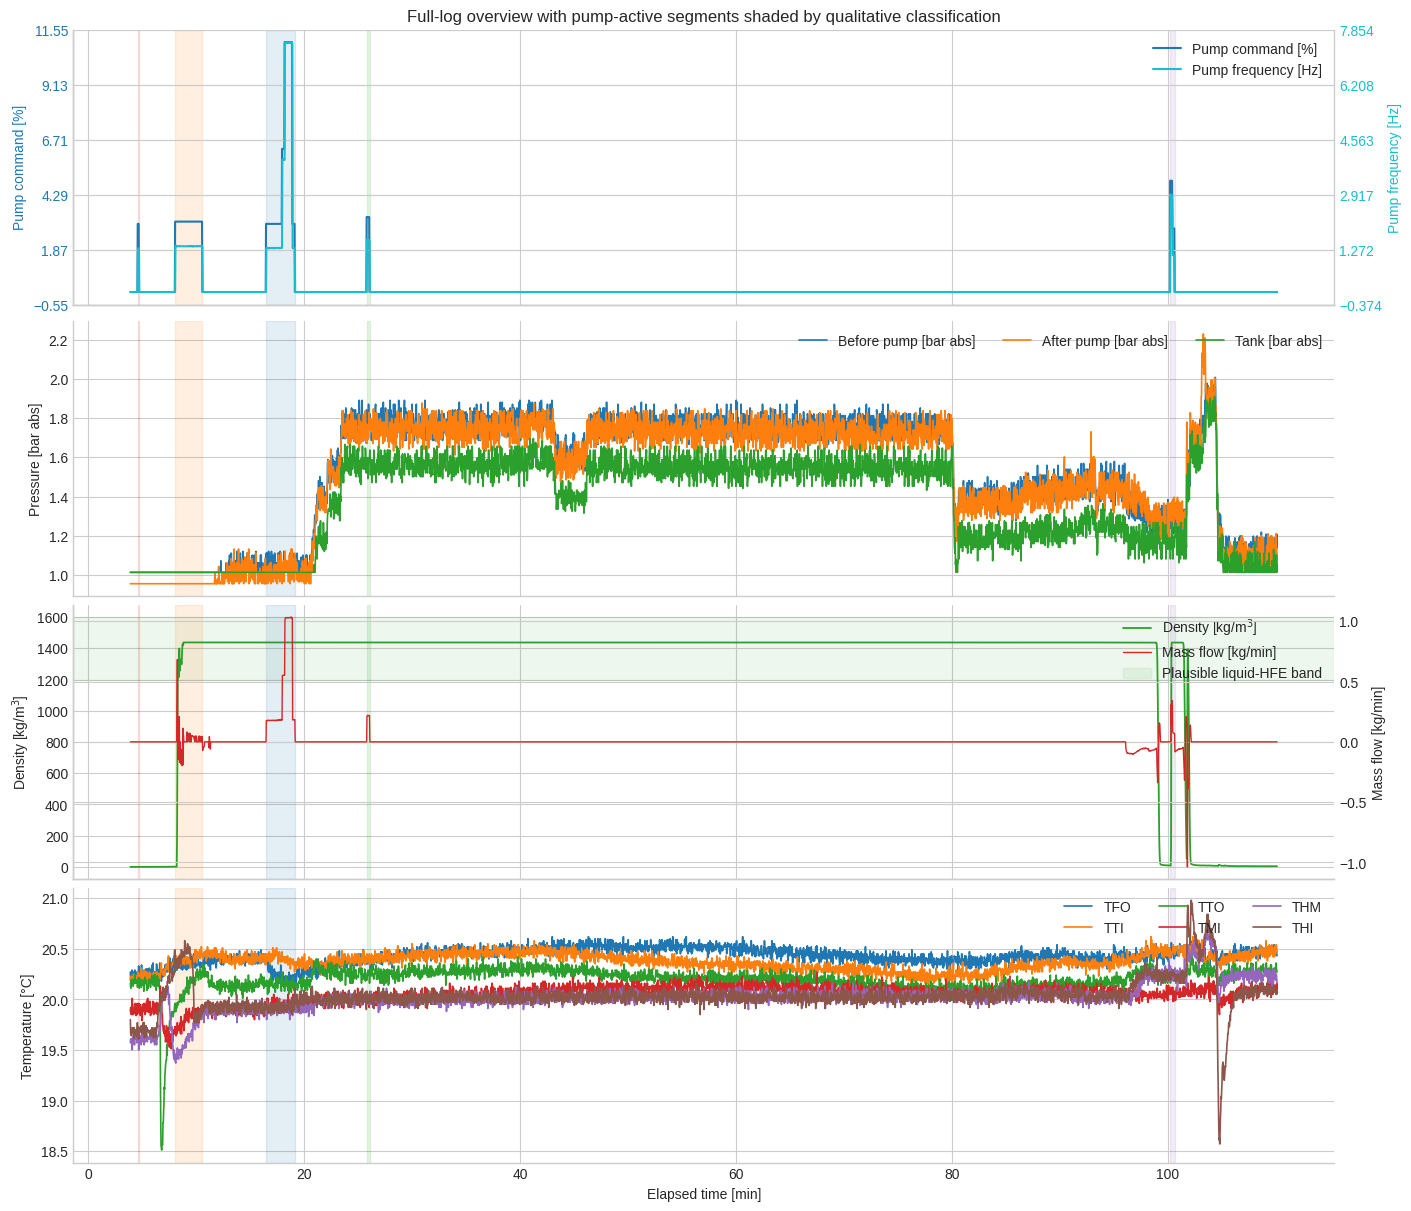

In [4]:
CLASS_COLORS = {
    'gas-rich / empty': '#d62728',
    'priming / flow-direction flips': '#ff7f0e',
    'draining tail / mixed phase': '#9467bd',
    'short usable window': '#2ca02c',
    'usable liquid circulation': '#1f77b4',
}


def shade_segments(ax, summary: pd.DataFrame) -> None:
    for _, row in summary.iterrows():
        color = CLASS_COLORS.get(row['classification'], '0.85')
        ax.axvspan(row['start_s'] / 60.0, row['end_s'] / 60.0, color=color, alpha=0.12)


fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

ax_pump_cmd = axes[0]
ax_pump_freq = ax_pump_cmd.twinx()
ax_pump_cmd.plot(df['t_min'], df['pump_cmd_pct'], label='Pump command [%]', lw=1.5, color='tab:blue')
ax_pump_freq.plot(df['t_min'], df['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.5, color='tab:cyan')
ax_pump_cmd.set_ylabel('Pump command [%]', color='tab:blue')
ax_pump_freq.set_ylabel('Pump frequency [Hz]', color='tab:cyan')
ax_pump_cmd.tick_params(axis='y', labelcolor='tab:blue')
ax_pump_freq.tick_params(axis='y', labelcolor='tab:cyan')
ax_pump_cmd.yaxis.set_major_locator(LinearLocator(6))
ax_pump_freq.yaxis.set_major_locator(LinearLocator(6))
ax_pump_freq.spines['right'].set_visible(True)
ax_pump_freq.yaxis.set_ticks_position('right')
shade_segments(ax_pump_cmd, segment_summary)
lines = ax_pump_cmd.get_lines() + ax_pump_freq.get_lines()
ax_pump_cmd.legend(lines, [line.get_label() for line in lines], loc='upper right')

axes[1].plot(df['t_min'], df['pump_pressure_before_bar_abs'], label='Before pump [bar abs]', lw=1.2)
axes[1].plot(df['t_min'], df['pump_pressure_after_bar_abs'], label='After pump [bar abs]', lw=1.2)
axes[1].plot(df['t_min'], df['pump_pressure_tank_bar_abs'], label='Tank [bar abs]', lw=1.2)
axes[1].set_ylabel('Pressure [bar abs]')
axes[1].legend(loc='upper right', ncols=3)
shade_segments(axes[1], segment_summary)

ax_density = axes[2]
ax_flow = ax_density.twinx()
ax_density.plot(df['t_min'], df['density_kg_m3_si'], color='tab:green', label='Density [kg/m$^3$]', lw=1.3)
ax_density.axhspan(*HFE_LIQUID_DENSITY_BOUNDS, color='tab:green', alpha=0.08, label='Plausible liquid-HFE band')
ax_flow.plot(df['t_min'], df['mass_flow_kgmin_si'], color='tab:red', label='Mass flow [kg/min]', lw=1.0)
ax_density.set_ylabel('Density [kg/m$^3$]')
ax_flow.set_ylabel('Mass flow [kg/min]')
shade_segments(ax_density, segment_summary)
lines = ax_density.get_lines() + ax_flow.get_lines()
labels = [line.get_label() for line in lines] + ['Plausible liquid-HFE band']
patch = plt.Rectangle((0, 0), 1, 1, color='tab:green', alpha=0.08)
ax_density.legend(lines + [patch], labels, loc='upper right')

for col in valid_temp_cols:
    axes[3].plot(df['t_min'], df[col], lw=1.2, label=orca.tc_display_name(col))
axes[3].set_ylabel('Temperature [°C]')
axes[3].set_xlabel('Elapsed time [min]')
axes[3].legend(loc='upper right', ncols=3)
shade_segments(axes[3], segment_summary)

axes[0].set_title('Full-log overview with pump-active segments shaded by qualitative classification')
plt.show()


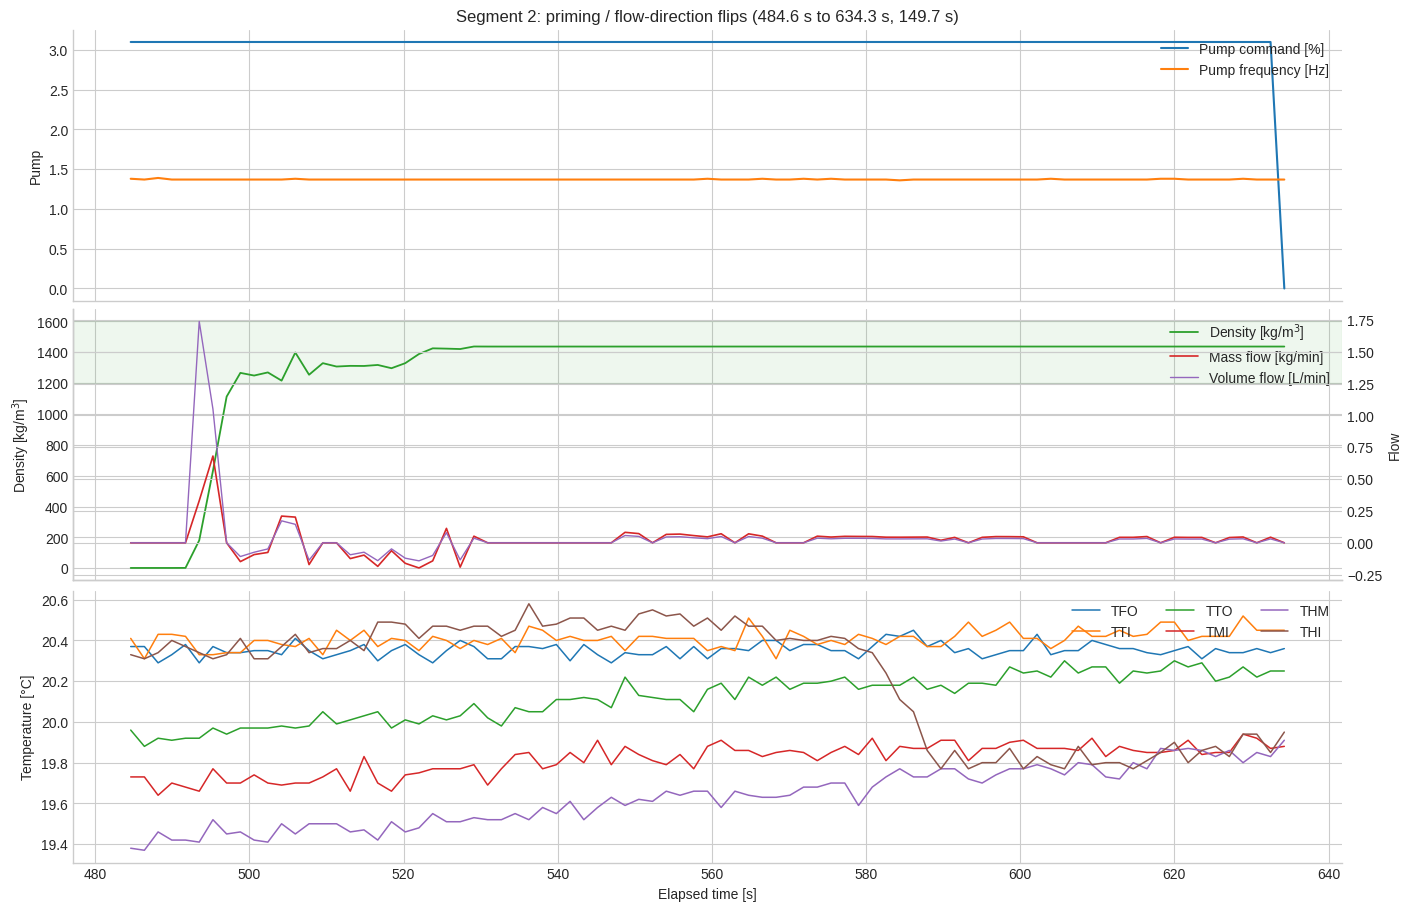

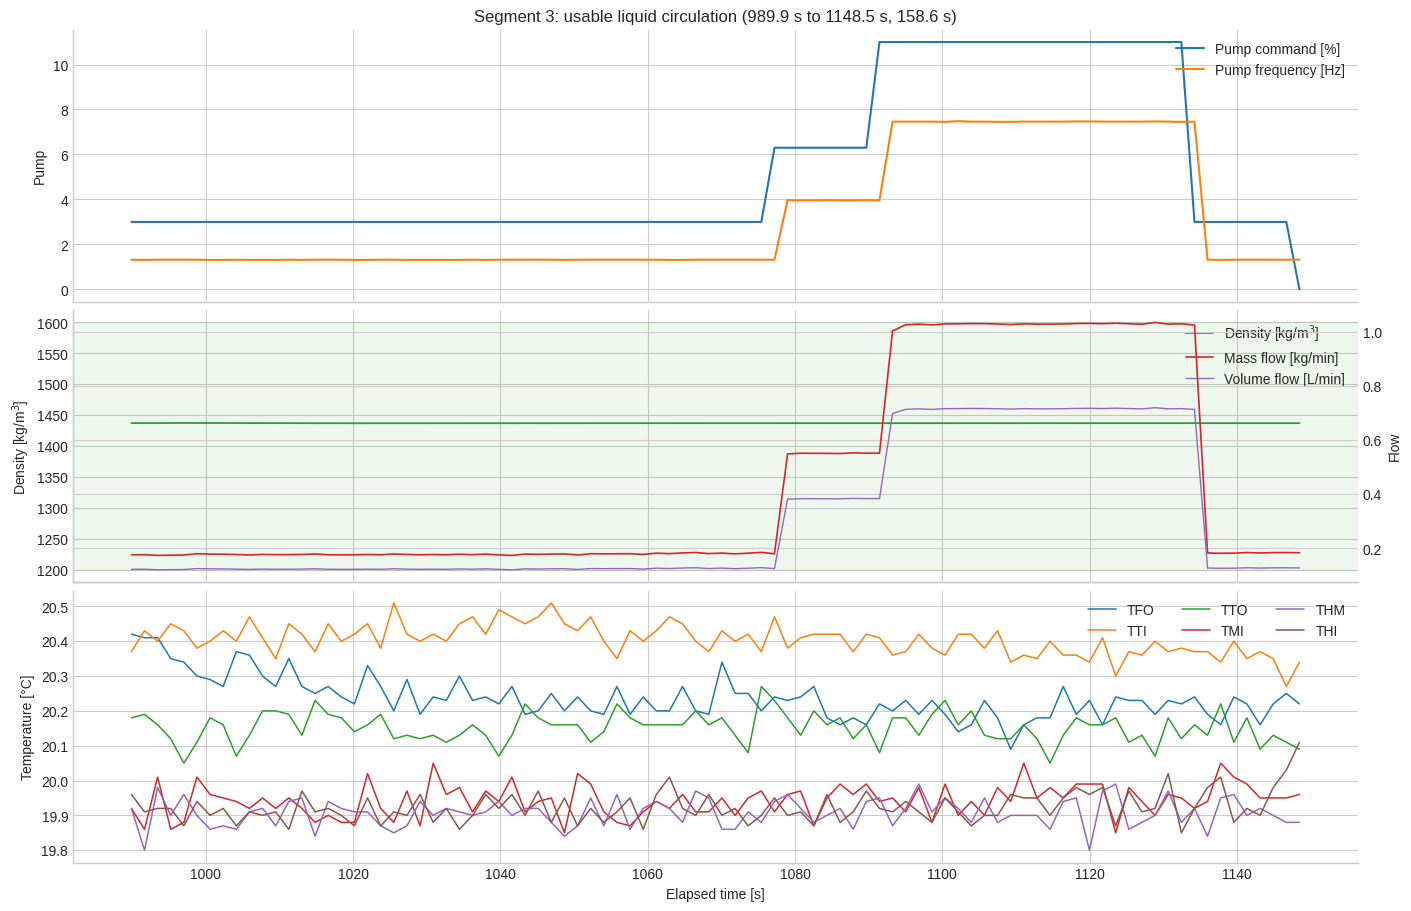

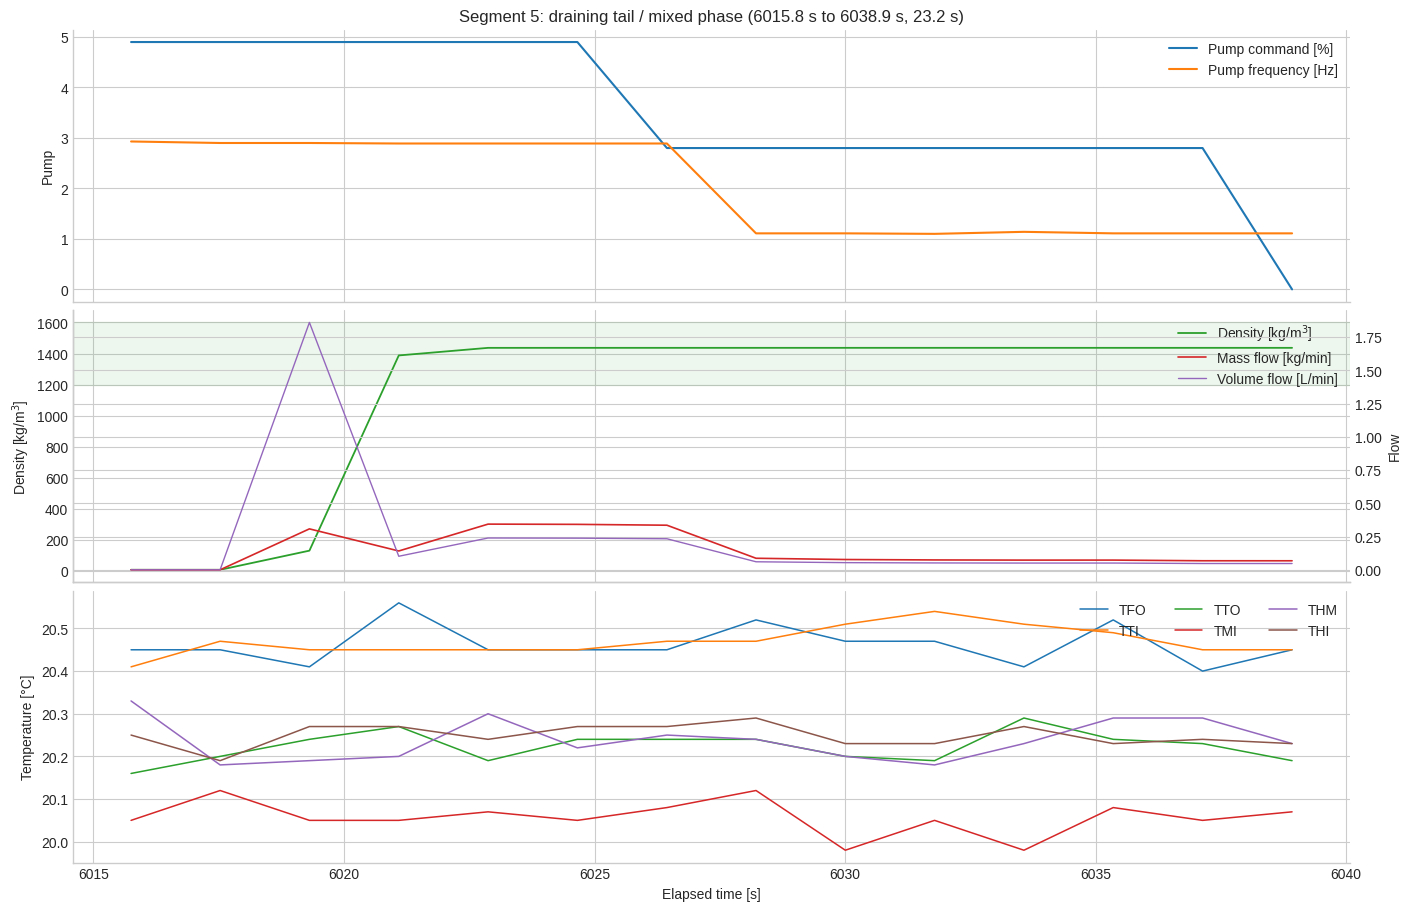

In [5]:
interesting_segments = segment_summary[segment_summary['duration_s'] >= 15.0].copy()

for segment_id, row in interesting_segments.iterrows():
    seg = segment_slice(df, row)
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

    axes[0].plot(seg['time_s'], seg['pump_cmd_pct'], label='Pump command [%]', lw=1.5)
    axes[0].plot(seg['time_s'], seg['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.5)
    axes[0].legend(loc='upper right')
    axes[0].set_ylabel('Pump')
    axes[0].set_title(
        f'Segment {segment_id}: {row["classification"]} '
        f'({row["start_s"]:.1f} s to {row["end_s"]:.1f} s, {row["duration_s"]:.1f} s)'
    )

    ax_density = axes[1]
    ax_flow = ax_density.twinx()
    ax_density.plot(seg['time_s'], seg['density_kg_m3_si'], color='tab:green', lw=1.3, label='Density [kg/m$^3$]')
    ax_density.axhspan(*HFE_LIQUID_DENSITY_BOUNDS, color='tab:green', alpha=0.08)
    ax_flow.plot(seg['time_s'], seg['mass_flow_kgmin_si'], color='tab:red', lw=1.2, label='Mass flow [kg/min]')
    ax_flow.plot(seg['time_s'], seg['volume_flow_lmin_si'], color='tab:purple', lw=1.0, label='Volume flow [L/min]')
    ax_density.set_ylabel('Density [kg/m$^3$]')
    ax_flow.set_ylabel('Flow')
    lines = ax_density.get_lines() + ax_flow.get_lines()
    labels = [line.get_label() for line in lines]
    ax_density.legend(lines, labels, loc='upper right')

    for col in valid_temp_cols:
        axes[2].plot(seg['time_s'], seg[col], lw=1.1, label=orca.tc_display_name(col))
    axes[2].set_ylabel('Temperature [°C]')
    axes[2].set_xlabel('Elapsed time [s]')
    axes[2].legend(loc='upper right', ncols=3)

    plt.show()


Segment 3 liquid-like duration: 156.8 s
Cumulative transferred mass: 1.162 kg
Cumulative transferred volume: 0.809 L
Settling cutoff for summary plots: 1.78 s after each command change
Flow-meter temperature traces below come from the meter temperature channel converted to `temperature_c_si`; the thermocouple map remains separate.


,median_velocity_mps,median_freq_hz,q10_freq_hz,q90_freq_hz,median_mass_flow_kgmin,q10_mass_flow_kgmin,q90_mass_flow_kgmin,median_volume_flow_lmin,q10_volume_flow_lmin,q90_volume_flow_lmin,median_density_kg_m3,median_flow_temp_C,median_temp_mean_C,median_temp_span_C,dwell_time_s,transferred_mass_kg,transferred_volume_l,sample_count
cmd_round,,,,,,,,,,,,,,,,,,
3.0,0.043,1.32,1.31,1.32,0.179,0.176,0.183,0.125,0.122,0.128,1437.115,20.029,20.098,0.540,94.447,0.282,0.196,53
6.3,0.134,3.96,3.96,3.97,0.551,0.551,0.553,0.384,0.383,0.384,1437.156,20.027,20.093,0.515,10.692,0.098,0.068,6
11.0,0.250,7.46,7.45,7.47,1.029,1.027,1.031,0.716,0.715,0.718,1437.145,20.035,20.081,0.480,39.209,0.673,0.468,22


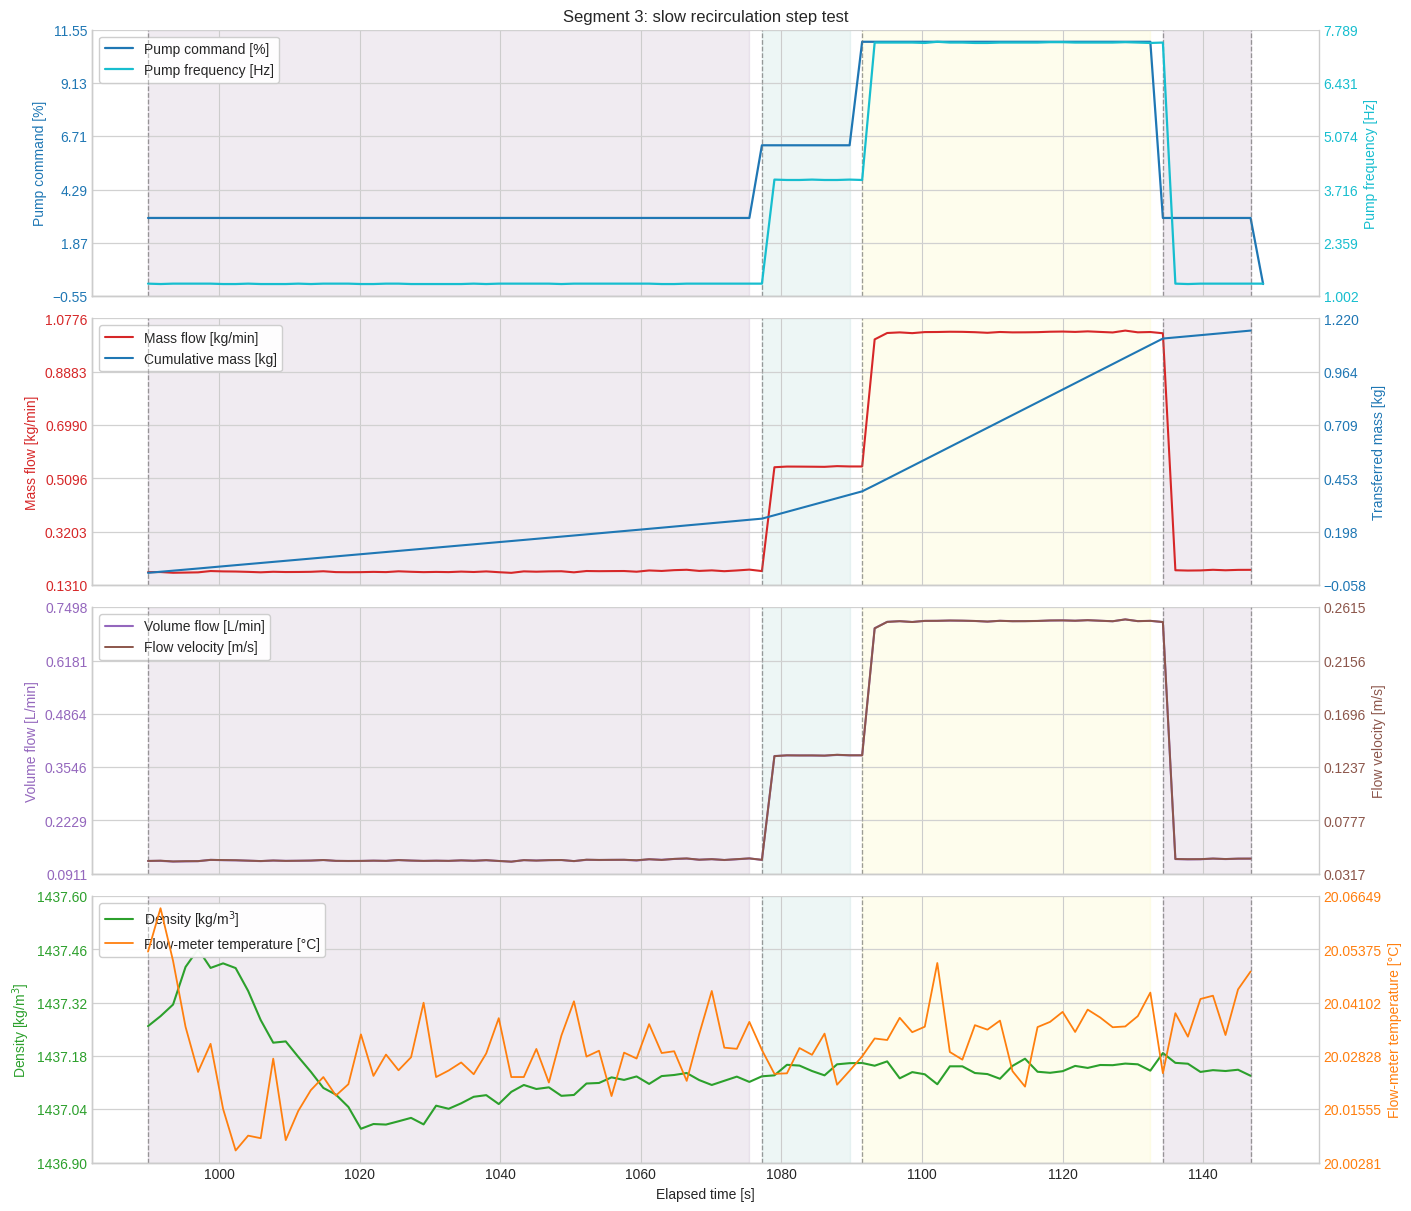

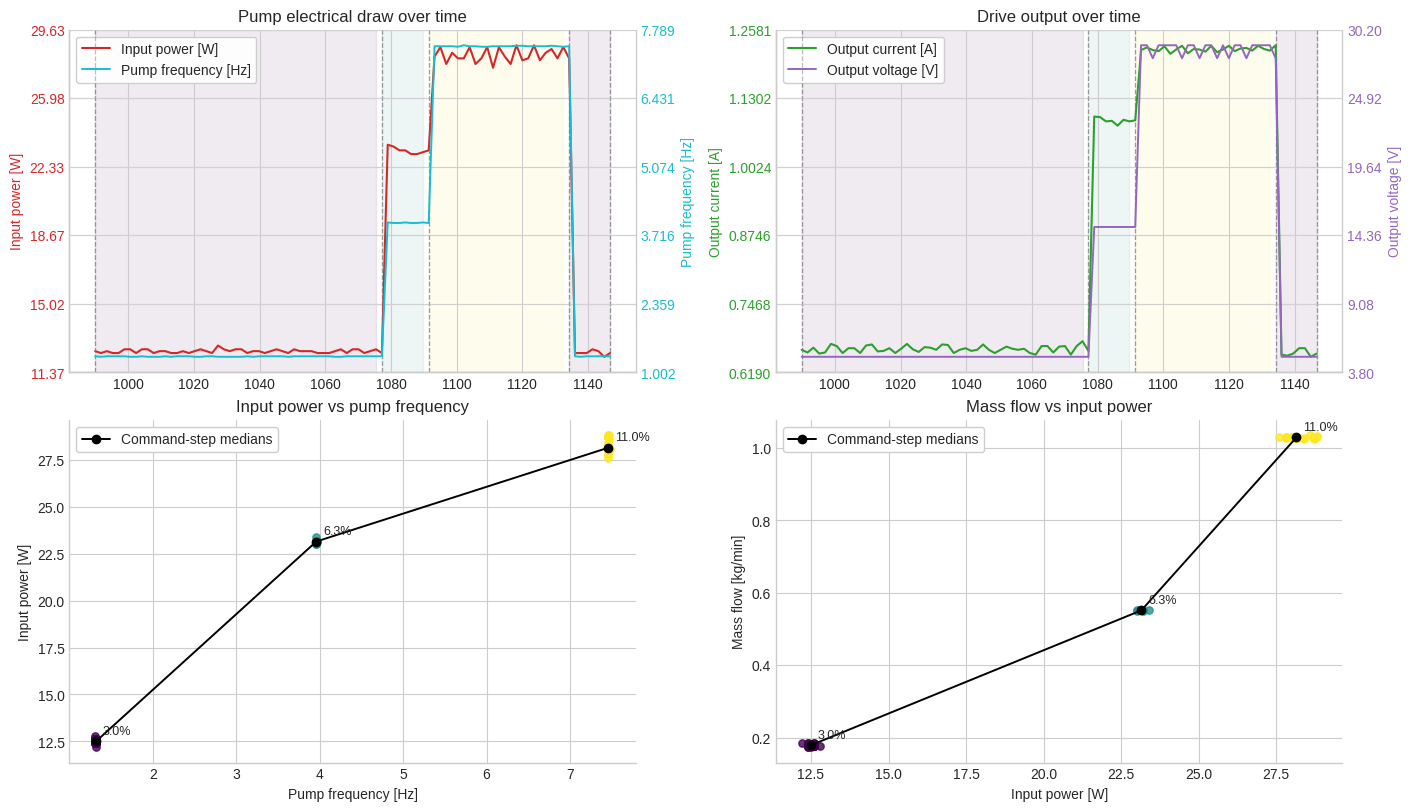

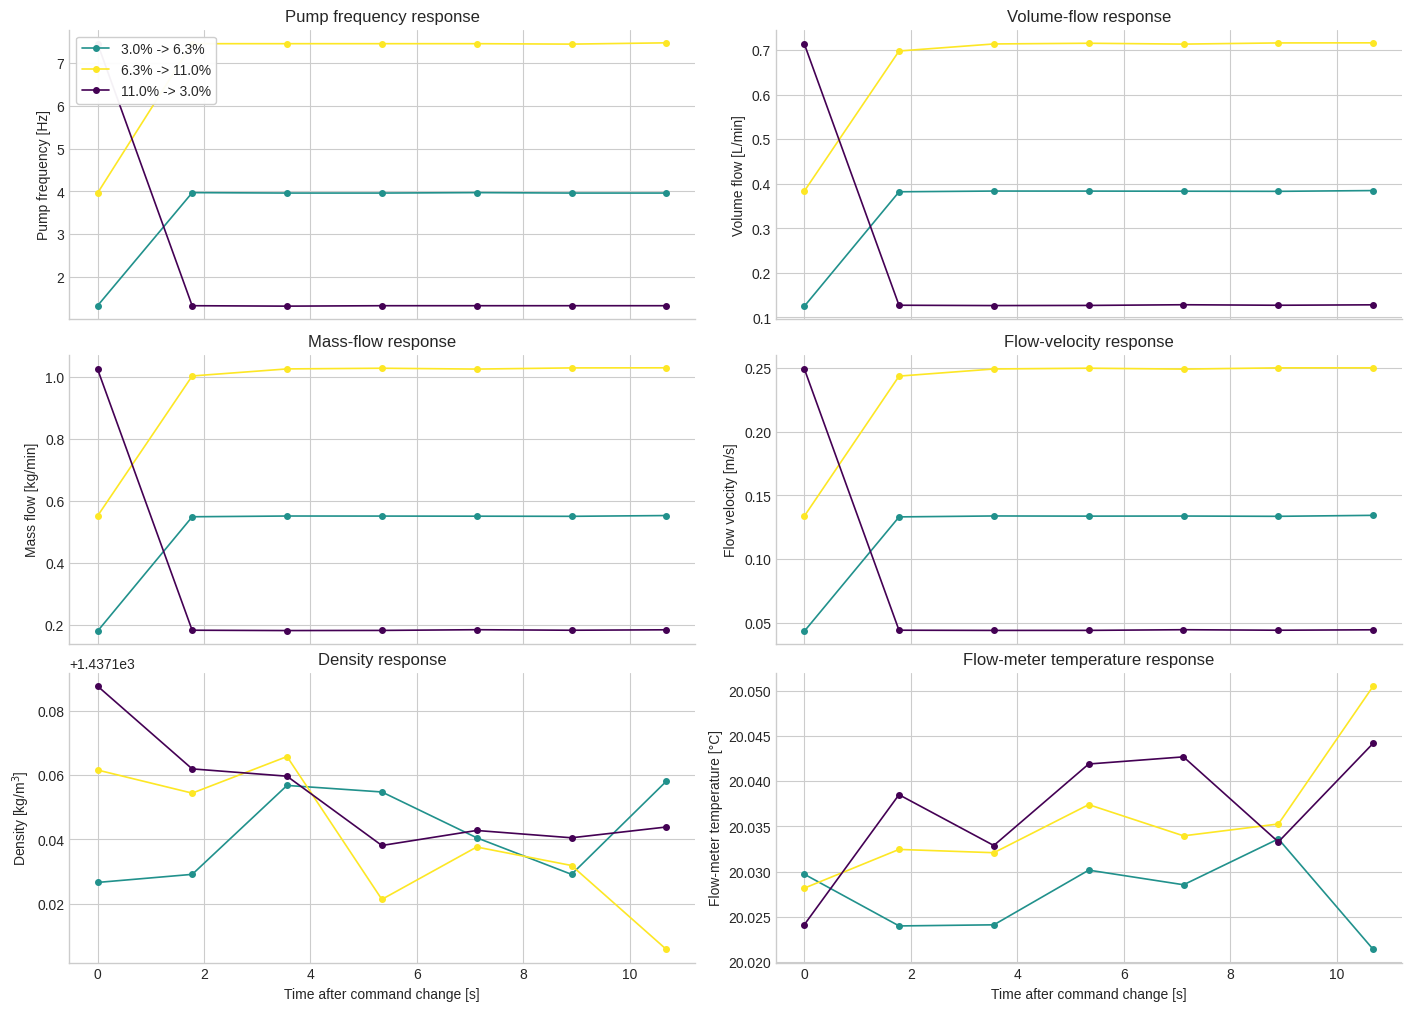

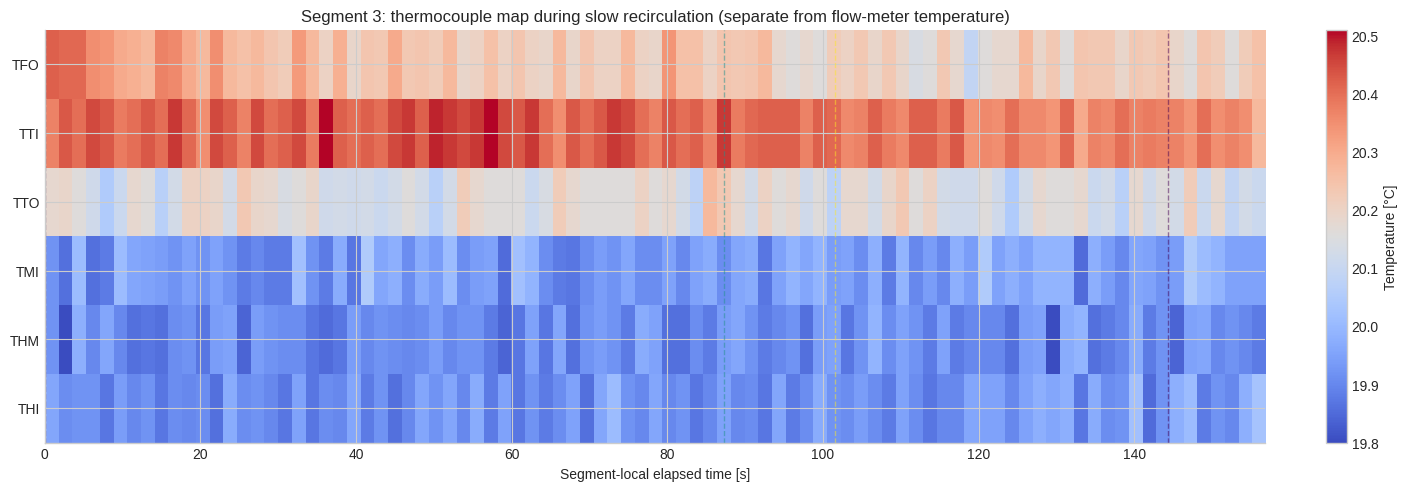

In [6]:
main_row = segment_summary.loc[main_segment_id]
main = segment_slice(df, main_row)
main_liquid = main[main['liquid_like_density'] & (main['pump_cmd_pct'] > 0.0)].copy()

main_liquid['cmd_round'] = main_liquid['pump_cmd_pct'].round(1)
main_liquid['elapsed_segment_s'] = main_liquid['time_s'] - main_liquid['time_s'].iloc[0]
main_liquid['dt_s'] = main_liquid['time_s'].diff().fillna(0.0).clip(lower=0.0)
main_liquid['mass_increment_kg'] = main_liquid['mass_flow_kgmin_si'] * main_liquid['dt_s'] / 60.0
main_liquid['volume_increment_l'] = main_liquid['volume_flow_lmin_si'] * main_liquid['dt_s'] / 60.0
main_liquid['cum_mass_kg'] = main_liquid['mass_increment_kg'].cumsum()
main_liquid['cum_volume_l'] = main_liquid['volume_increment_l'].cumsum()
main_liquid['flow_meter_temp_c'] = main_liquid['temperature_c_si']

if valid_temp_cols:
    main_liquid['temp_mean_C'] = main_liquid[valid_temp_cols].mean(axis=1)
    main_liquid['temp_span_C'] = main_liquid[valid_temp_cols].max(axis=1) - main_liquid[valid_temp_cols].min(axis=1)
else:
    main_liquid['temp_mean_C'] = np.nan
    main_liquid['temp_span_C'] = np.nan

command_change = main_liquid['cmd_round'].ne(main_liquid['cmd_round'].shift(fill_value=main_liquid['cmd_round'].iloc[0]))
main_liquid['step_id'] = command_change.cumsum()
main_liquid['time_from_step_s'] = main_liquid.groupby('step_id')['time_s'].transform(lambda s: s - s.iloc[0])

step_windows = (
    main_liquid.groupby('step_id')
    .agg(
        cmd_pct=('cmd_round', 'first'),
        start_s=('time_s', 'min'),
        end_s=('time_s', 'max'),
        duration_s=('time_s', lambda s: s.iloc[-1] - s.iloc[0]),
        median_freq_hz=('pump_freq_hz', 'median'),
        median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
        median_volume_flow_lmin=('volume_flow_lmin_si', 'median'),
    )
    .sort_index()
)

settled_cutoff_s = main_liquid['dt_s'].median()
settled = main_liquid[main_liquid['time_from_step_s'] >= settled_cutoff_s].copy()
if settled.empty:
    settled = main_liquid.copy()

step_summary = (
    settled.groupby('cmd_round')
    .agg(
        median_velocity_mps=('flow_velocity_mps_si', 'median'),
        median_freq_hz=('pump_freq_hz', 'median'),
        q10_freq_hz=('pump_freq_hz', lambda s: s.quantile(0.10)),
        q90_freq_hz=('pump_freq_hz', lambda s: s.quantile(0.90)),
        median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
        q10_mass_flow_kgmin=('mass_flow_kgmin_si', lambda s: s.quantile(0.10)),
        q90_mass_flow_kgmin=('mass_flow_kgmin_si', lambda s: s.quantile(0.90)),
        median_volume_flow_lmin=('volume_flow_lmin_si', 'median'),
        q10_volume_flow_lmin=('volume_flow_lmin_si', lambda s: s.quantile(0.10)),
        q90_volume_flow_lmin=('volume_flow_lmin_si', lambda s: s.quantile(0.90)),
        median_density_kg_m3=('density_kg_m3_si', 'median'),
        median_flow_temp_C=('flow_meter_temp_c', 'median'),
        median_temp_mean_C=('temp_mean_C', 'median'),
        median_temp_span_C=('temp_span_C', 'median'),
        dwell_time_s=('dt_s', 'sum'),
        transferred_mass_kg=('mass_increment_kg', 'sum'),
        transferred_volume_l=('volume_increment_l', 'sum'),
        sample_count=('pump_freq_hz', 'size'),
    )
    .sort_index()
)

pump_summary = (
    settled.assign(flow_per_w_kgmin_per_w=settled['mass_flow_kgmin_si'] / settled['pump_input_power_w'])
    .groupby('cmd_round')
    .agg(
        median_freq_hz=('pump_freq_hz', 'median'),
        median_input_power_w=('pump_input_power_w', 'median'),
        median_output_current_a=('pump_output_current_a', 'median'),
        median_output_voltage_v=('pump_output_voltage_v', 'median'),
        median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
        median_flow_per_w_kgmin_per_w=('flow_per_w_kgmin_per_w', 'median'),
    )
    .sort_index()
)

cmd_levels = step_summary.index.to_list()
command_colors = {
    cmd: plt.cm.viridis(idx / max(len(cmd_levels) - 1, 1))
    for idx, cmd in enumerate(cmd_levels)
}
legend_style = dict(frameon=True, facecolor='white', framealpha=0.95, edgecolor='0.8')
boundary_times = step_windows['start_s'].tolist() + [step_windows['end_s'].iloc[-1]]
density_min = main_liquid['density_kg_m3_si'].min()
density_max = main_liquid['density_kg_m3_si'].max()
density_pad = max(0.05, 0.15 * (density_max - density_min))
density_ylim = (
    np.floor((density_min - density_pad) * 10.0) / 10.0,
    np.ceil((density_max + density_pad) * 10.0) / 10.0,
)

def draw_step_regions(*plot_axes):
    for _, step in step_windows.iterrows():
        color = command_colors[step['cmd_pct']]
        for plot_ax in plot_axes:
            plot_ax.axvspan(step['start_s'], step['end_s'], color=color, alpha=0.08, zorder=0)

def draw_step_boundaries(*plot_axes):
    for boundary_s in boundary_times:
        for plot_ax in plot_axes:
            plot_ax.axvline(boundary_s, color='0.45', lw=0.9, ls='--', alpha=0.45, zorder=0)

def sync_twin_y_axes(primary_ax, secondary_ax, tick_count=6):
    primary_ax.yaxis.set_major_locator(LinearLocator(tick_count))
    secondary_ax.yaxis.set_major_locator(LinearLocator(tick_count))
    primary_ax.grid(True, axis='y', color='0.82', linewidth=0.9)
    secondary_ax.grid(False)
    secondary_ax.spines['right'].set_visible(True)
    secondary_ax.yaxis.set_ticks_position('right')

def combined_legend(primary_ax, secondary_ax=None, **kwargs):
    lines = primary_ax.get_lines()
    if secondary_ax is not None:
        lines = lines + secondary_ax.get_lines()
    lines = [line for line in lines if not line.get_label().startswith('_')]
    labels = [line.get_label() for line in lines]
    return primary_ax.legend(lines, labels, **legend_style, **kwargs)

print(f'Segment {main_segment_id} liquid-like duration: {main_liquid["dt_s"].sum():.1f} s')
print(f'Cumulative transferred mass: {main_liquid["mass_increment_kg"].sum():.3f} kg')
print(f'Cumulative transferred volume: {main_liquid["volume_increment_l"].sum():.3f} L')
print(f'Settling cutoff for summary plots: {settled_cutoff_s:.2f} s after each command change')
print('Flow-meter temperature traces below come from the meter temperature channel converted to `temperature_c_si`; the thermocouple map remains separate.')
display(step_summary.round(3))

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

pump_cmd_ax = axes[0]
pump_cmd_ax.plot(main['time_s'], main['pump_cmd_pct'], label='Pump command [%]', lw=1.6, color='tab:blue')
pump_cmd_ax.set_ylabel('Pump command [%]', color='tab:blue')
pump_cmd_ax.tick_params(axis='y', labelcolor='tab:blue')
pump_freq_ax = pump_cmd_ax.twinx()
pump_freq_ax.plot(main['time_s'], main['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.6, color='tab:cyan')
pump_freq_ax.set_ylabel('Pump frequency [Hz]', color='tab:cyan')
pump_freq_ax.tick_params(axis='y', labelcolor='tab:cyan')
draw_step_regions(pump_cmd_ax)
draw_step_boundaries(pump_cmd_ax, pump_freq_ax)
sync_twin_y_axes(pump_cmd_ax, pump_freq_ax)
combined_legend(pump_cmd_ax, pump_freq_ax, loc='upper left')
pump_cmd_ax.set_title(f'Segment {main_segment_id}: slow recirculation step test')

mass_ax = axes[1]
mass_ax.plot(main_liquid['time_s'], main_liquid['mass_flow_kgmin_si'], label='Mass flow [kg/min]', lw=1.5, color='tab:red')
mass_ax.set_ylabel('Mass flow [kg/min]', color='tab:red')
mass_ax.tick_params(axis='y', labelcolor='tab:red')
mass_total_ax = mass_ax.twinx()
mass_total_ax.plot(main_liquid['time_s'], main_liquid['cum_mass_kg'], label='Cumulative mass [kg]', lw=1.5, color='tab:blue')
mass_total_ax.set_ylabel('Transferred mass [kg]', color='tab:blue')
mass_total_ax.tick_params(axis='y', labelcolor='tab:blue')
draw_step_regions(mass_ax)
draw_step_boundaries(mass_ax, mass_total_ax)
sync_twin_y_axes(mass_ax, mass_total_ax)
combined_legend(mass_ax, mass_total_ax, loc='upper left')

volume_ax = axes[2]
volume_ax.plot(main_liquid['time_s'], main_liquid['volume_flow_lmin_si'], label='Volume flow [L/min]', lw=1.5, color='tab:purple')
volume_ax.set_ylabel('Volume flow [L/min]', color='tab:purple')
volume_ax.tick_params(axis='y', labelcolor='tab:purple')
velocity_ax = volume_ax.twinx()
velocity_ax.plot(main_liquid['time_s'], main_liquid['flow_velocity_mps_si'], label='Flow velocity [m/s]', lw=1.4, color='tab:brown')
velocity_ax.set_ylabel('Flow velocity [m/s]', color='tab:brown')
velocity_ax.tick_params(axis='y', labelcolor='tab:brown')
draw_step_regions(volume_ax)
draw_step_boundaries(volume_ax, velocity_ax)
sync_twin_y_axes(volume_ax, velocity_ax)
combined_legend(volume_ax, velocity_ax, loc='upper left')

density_ax = axes[3]
density_ax.plot(main_liquid['time_s'], main_liquid['density_kg_m3_si'], label='Density [kg/m$^3$]', lw=1.5, color='tab:green')
density_ax.set_ylabel('Density [kg/m$^3$]', color='tab:green')
density_ax.tick_params(axis='y', labelcolor='tab:green')
density_ax.set_ylim(*density_ylim)
temp_ax = density_ax.twinx()
temp_ax.plot(main_liquid['time_s'], main_liquid['flow_meter_temp_c'], label='Flow-meter temperature [°C]', lw=1.3, color='tab:orange')
temp_ax.set_ylabel('Flow-meter temperature [°C]', color='tab:orange')
temp_ax.tick_params(axis='y', labelcolor='tab:orange')
draw_step_regions(density_ax)
draw_step_boundaries(density_ax, temp_ax)
sync_twin_y_axes(density_ax, temp_ax)
combined_legend(density_ax, temp_ax, loc='upper left')
density_ax.set_xlabel('Elapsed time [s]')

plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

power_ax = axes[0, 0]
power_ax.plot(main_liquid['time_s'], main_liquid['pump_input_power_w'], label='Input power [W]', lw=1.5, color='tab:red')
power_ax.set_ylabel('Input power [W]', color='tab:red')
power_ax.tick_params(axis='y', labelcolor='tab:red')
power_freq_ax = power_ax.twinx()
power_freq_ax.plot(main_liquid['time_s'], main_liquid['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.4, color='tab:cyan')
power_freq_ax.set_ylabel('Pump frequency [Hz]', color='tab:cyan')
power_freq_ax.tick_params(axis='y', labelcolor='tab:cyan')
draw_step_regions(power_ax)
draw_step_boundaries(power_ax, power_freq_ax)
sync_twin_y_axes(power_ax, power_freq_ax)
combined_legend(power_ax, power_freq_ax, loc='upper left')
power_ax.set_title('Pump electrical draw over time')

current_ax = axes[0, 1]
current_ax.plot(main_liquid['time_s'], main_liquid['pump_output_current_a'], label='Output current [A]', lw=1.5, color='tab:green')
current_ax.set_ylabel('Output current [A]', color='tab:green')
current_ax.tick_params(axis='y', labelcolor='tab:green')
voltage_ax = current_ax.twinx()
voltage_ax.plot(main_liquid['time_s'], main_liquid['pump_output_voltage_v'], label='Output voltage [V]', lw=1.4, color='tab:purple')
voltage_ax.set_ylabel('Output voltage [V]', color='tab:purple')
voltage_ax.tick_params(axis='y', labelcolor='tab:purple')
draw_step_regions(current_ax)
draw_step_boundaries(current_ax, voltage_ax)
sync_twin_y_axes(current_ax, voltage_ax)
combined_legend(current_ax, voltage_ax, loc='upper left')
current_ax.set_title('Drive output over time')

for cmd in cmd_levels:
    subset = settled[settled['cmd_round'] == cmd]
    color = command_colors[cmd]
    axes[1, 0].scatter(subset['pump_freq_hz'], subset['pump_input_power_w'], s=28, alpha=0.8, color=color)
axes[1, 0].plot(
    pump_summary['median_freq_hz'],
    pump_summary['median_input_power_w'],
    color='black',
    marker='o',
    lw=1.4,
    label='Command-step medians',
)
for cmd, row in pump_summary.iterrows():
    axes[1, 0].annotate(f'{cmd:.1f}%', (row['median_freq_hz'], row['median_input_power_w']), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1, 0].set_xlabel('Pump frequency [Hz]')
axes[1, 0].set_ylabel('Input power [W]')
axes[1, 0].set_title('Input power vs pump frequency')
axes[1, 0].legend(loc='upper left', **legend_style)

for cmd in cmd_levels:
    subset = settled[settled['cmd_round'] == cmd]
    color = command_colors[cmd]
    axes[1, 1].scatter(subset['pump_input_power_w'], subset['mass_flow_kgmin_si'], s=28, alpha=0.8, color=color)
axes[1, 1].plot(
    pump_summary['median_input_power_w'],
    pump_summary['median_mass_flow_kgmin'],
    color='black',
    marker='o',
    lw=1.4,
    label='Command-step medians',
)
for cmd, row in pump_summary.iterrows():
    axes[1, 1].annotate(f'{cmd:.1f}%', (row['median_input_power_w'], row['median_mass_flow_kgmin']), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1, 1].set_xlabel('Input power [W]')
axes[1, 1].set_ylabel('Mass flow [kg/min]')
axes[1, 1].set_title('Mass flow vs input power')
axes[1, 1].legend(loc='upper left', **legend_style)

plt.show()

response_window_s = 12.0
transition_ids = step_windows.index[step_windows.index > step_windows.index.min()]
fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True, sharex=True)
response_specs = [
    ((0, 0), 'pump_freq_hz', 'Pump frequency [Hz]', 'Pump frequency response'),
    ((0, 1), 'volume_flow_lmin_si', 'Volume flow [L/min]', 'Volume-flow response'),
    ((1, 0), 'mass_flow_kgmin_si', 'Mass flow [kg/min]', 'Mass-flow response'),
    ((1, 1), 'flow_velocity_mps_si', 'Flow velocity [m/s]', 'Flow-velocity response'),
    ((2, 0), 'density_kg_m3_si', 'Density [kg/m$^3$]', 'Density response'),
    ((2, 1), 'flow_meter_temp_c', 'Flow-meter temperature [°C]', 'Flow-meter temperature response'),
]

for step_id in transition_ids:
    subset = main_liquid[(main_liquid['step_id'] == step_id) & (main_liquid['time_from_step_s'] <= response_window_s)]
    prev_cmd = step_windows.loc[step_id - 1, 'cmd_pct']
    cmd = step_windows.loc[step_id, 'cmd_pct']
    label = f'{prev_cmd:.1f}% -> {cmd:.1f}%'
    color = command_colors[cmd]
    for (row, col), value_col, ylabel, title in response_specs:
        axes[row, col].plot(subset['time_from_step_s'], subset[value_col], marker='o', ms=4, lw=1.2, color=color, label=label)

for (row, col), _, ylabel, title in response_specs:
    axes[row, col].set_title(title)
    axes[row, col].set_ylabel(ylabel)

axes[0, 0].legend(loc='upper left', **legend_style)
axes[2, 0].set_xlabel('Time after command change [s]')
axes[2, 1].set_xlabel('Time after command change [s]')

plt.show()

if valid_temp_cols:
    fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
    temp_map = main_liquid[valid_temp_cols].to_numpy().T
    image = ax.imshow(
        temp_map,
        aspect='auto',
        interpolation='nearest',
        cmap='coolwarm',
        extent=[
            main_liquid['elapsed_segment_s'].min(),
            main_liquid['elapsed_segment_s'].max(),
            len(valid_temp_cols) - 0.5,
            -0.5,
        ],
    )
    ax.set_yticks(range(len(valid_temp_cols)), labels=[orca.tc_display_name(c) for c in valid_temp_cols])
    ax.set_xlabel('Segment-local elapsed time [s]')
    ax.set_title(f'Segment {main_segment_id}: thermocouple map during slow recirculation (separate from flow-meter temperature)')
    for _, step in step_windows.iterrows():
        ax.axvline(step['start_s'] - main_liquid['time_s'].iloc[0], color=command_colors[step['cmd_pct']], lw=1.0, ls='--', alpha=0.5)
    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label('Temperature [°C]')
    plt.show()


## Reading The Plots

For this log, the segment summary should be read qualitatively as follows:

- **Segment 1** is essentially an empty / gas-rich blip.
- **Segment 2** looks like priming or a fill / drain transition: the density is often liquid-like, but the signed flow flips around and the interval is not reliable for clean flow calibration.
- **Segment 3** is the main usable slow-recirculation window and is the best place to compare pump setting against measured flow.
- **Segment 4** is short but still liquid-like.
- **Segment 5** is a short late tail that looks partially drained or in transition, so it is useful mainly for qualitative inspection.

If you later regenerate this log with the cleaned supervisor pipeline, most of the conversion logic in this notebook should collapse away and the same segment logic can still be reused.
